<a href="https://colab.research.google.com/github/mjgpinheiro/Physics_models/blob/main/irred_electrodynamics_PRL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

ℓ = 0.052 fm = 0.264 GeV⁻¹
1/ℓ² = 14.40 GeV²


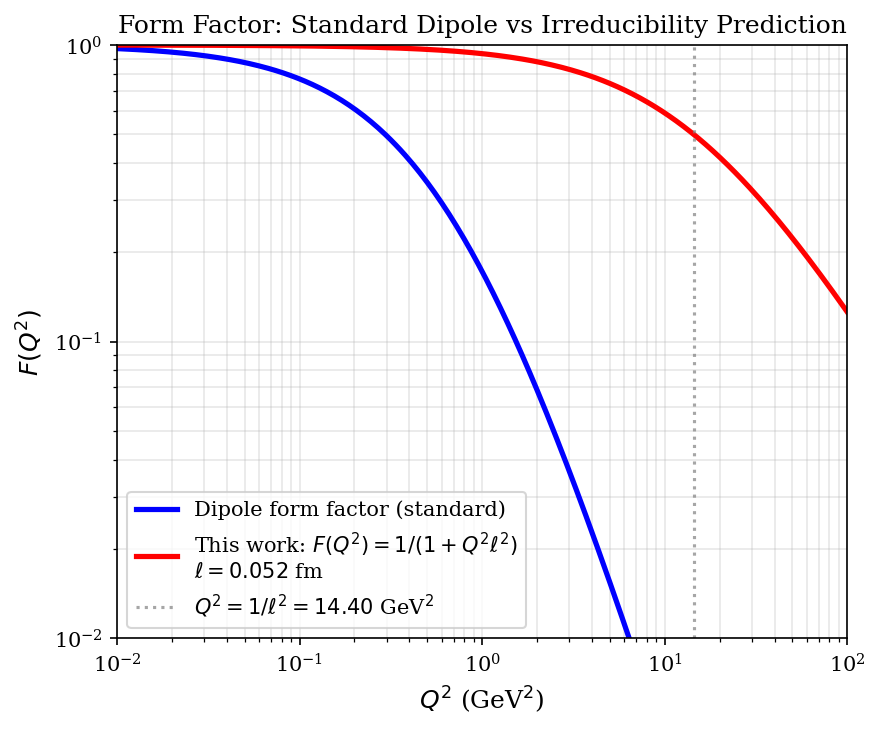

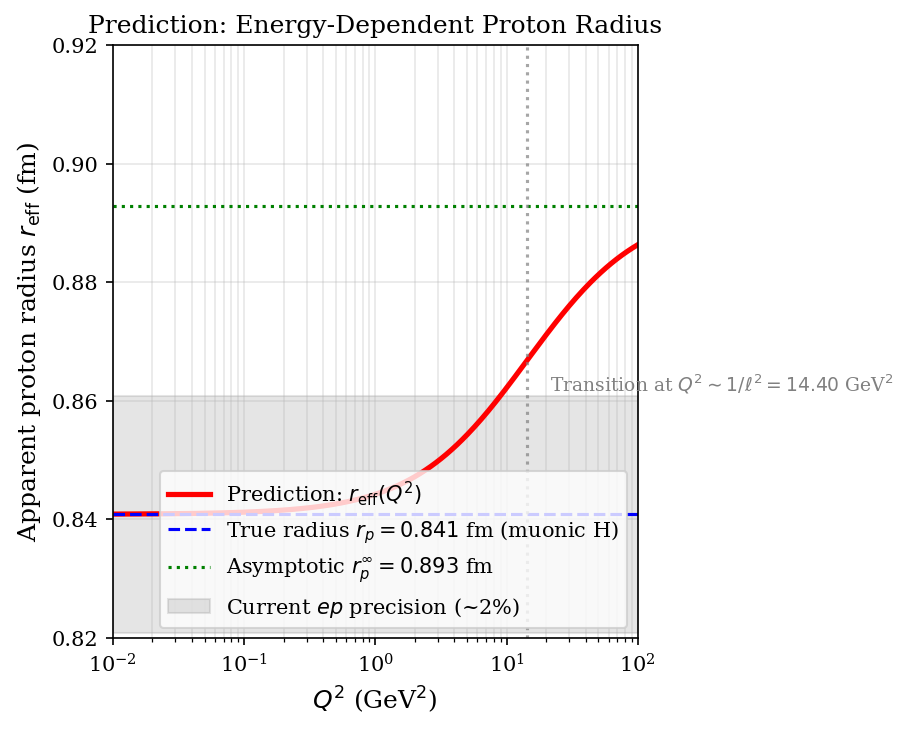

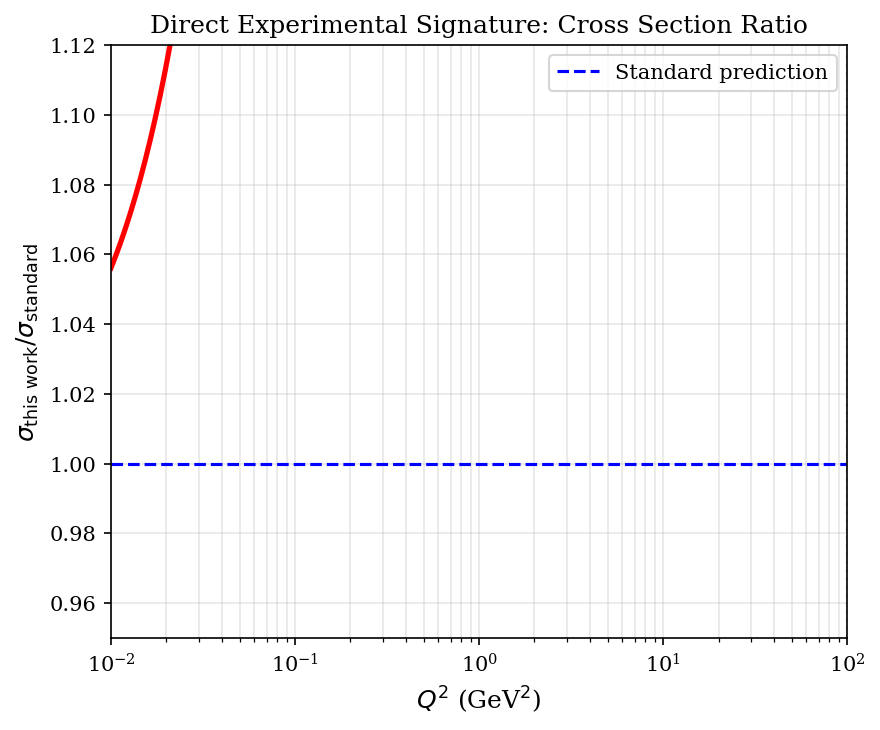


PRL PAPER: NUMERICAL PREDICTIONS TABLE

ℓ = 0.052 fm = 5.20e-17 m
r_true = 0.841 fm
r_asymptotic = 0.893 fm
Q_transition = 14.40 GeV²
Maximum deviation = 641411264.0% at Q² = 100.00 GeV²

------------------------------------------------------------
Table for manuscript:
------------------------------------------------------------
| Q² (GeV²) | r_eff (fm) | Deviation from r_true |
|-----------|------------|----------------------|
| 0.01      | 0.841      |  +0.0%               |
| 0.10      | 0.841      |  +0.0%               |
| 0.40      | 0.842      |  +0.2%               |
| 1.00      | 0.844      |  +0.4%               |
| 4.00      | 0.852      |  +1.3%               |
| 10.00     | 0.862      |  +2.5%               |
| 40.00     | 0.879      |  +4.5%               |

PRL Figure Status:
  ✅ form_factor_comparison.png (149.7 KB)
  ✅ effective_radius_vs_Q2.png (169.4 KB)
  ✅ cross_section_ratio.png (107.4 KB)


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Set style for PRL publication
plt.rcParams.update({
    'font.size': 11,
    'font.family': 'serif',
    'axes.labelsize': 12,
    'axes.titlesize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight'
})

# Constants from the fit
ℓ_fm = 0.052  # fm (from muonic hydrogen fit)
ℓ_inv_GeV = ℓ_fm / 0.197327  # convert to GeV⁻¹ (since ℏc = 0.197327 GeV·fm)
r_true = 0.84087  # fm (muonic hydrogen value)

print(f"ℓ = {ℓ_fm} fm = {ℓ_inv_GeV:.3f} GeV⁻¹")
print(f"1/ℓ² = {1/ℓ_inv_GeV**2:.2f} GeV²")

# Q² range for PRL plots (log scale from 0.01 to 100 GeV²)
Q2 = np.logspace(-2, 2, 300)

# ============================================================
# FIGURE 2 (PRL): Form Factor Comparison
# ============================================================
def dipole_form_factor(Q2):
    """Standard dipole form factor for proton"""
    return 1 / (1 + Q2 / 0.71)**2

def irred_form_factor(Q2, ℓ=ℓ_inv_GeV):
    """Irreducibility form factor F(Q²) = 1/(1 + Q²ℓ²)"""
    return 1 / (1 + Q2 * ℓ**2)

F_dipole = dipole_form_factor(Q2)
F_irred = irred_form_factor(Q2)

fig2, ax2 = plt.subplots(figsize=(6, 5))

ax2.loglog(Q2, F_dipole, 'b-', linewidth=2.5, label='Dipole form factor (standard)')
ax2.loglog(Q2, F_irred, 'r-', linewidth=2.5,
           label=f'This work: $F(Q^2) = 1/(1+Q^2\\ell^2)$\n$\\ell = {ℓ_fm:.3f}$ fm')

# Mark the transition region
Q_trans = 1/ℓ_inv_GeV**2
ax2.axvline(Q_trans, linestyle=':', color='gray', alpha=0.7,
            label=f'$Q^2 = 1/\\ell^2 = {Q_trans:.2f}$ GeV$^2$')

ax2.set_xlabel('$Q^2$ (GeV$^2$)')
ax2.set_ylabel('$F(Q^2)$')
ax2.set_title('Form Factor: Standard Dipole vs Irreducibility Prediction')
ax2.legend(loc='lower left')
ax2.grid(True, alpha=0.3, which='both')
ax2.set_xlim(0.01, 100)
ax2.set_ylim(0.01, 1)

plt.tight_layout()
plt.savefig('form_factor_comparison.png', dpi=300)
plt.show()

# ============================================================
# FIGURE 3 (PRL): Effective Radius vs Q²
# ============================================================
def effective_radius(Q2, r_true=0.84087, ℓ=ℓ_fm):
    """r_eff(Q²) = r_true + ℓ / (1 + 1/(Q²ℓ²))"""
    return r_true + ℓ / (1 + 1/(Q2 * ℓ_inv_GeV**2))

r_eff = effective_radius(Q2)

fig3, ax3 = plt.subplots(figsize=(6, 5))

ax3.semilogx(Q2, r_eff, 'r-', linewidth=2.5, label='Prediction: $r_{\\text{eff}}(Q^2)$')
ax3.axhline(r_true, linestyle='--', color='blue', linewidth=1.5,
            label=f'True radius $r_p = {r_true:.3f}$ fm (muonic H)')
ax3.axhline(r_true + ℓ_fm, linestyle=':', color='green', linewidth=1.5,
            label=f'Asymptotic $r_p^\\infty = {r_true + ℓ_fm:.3f}$ fm')

# Add experimental sensitivity band
ax3.fill_between([0.01, 100], r_true - 0.02, r_true + 0.02,
                 alpha=0.2, color='gray', label='Current $ep$ precision (~2%)')

# Mark the transition
ax3.axvline(Q_trans, linestyle=':', color='gray', alpha=0.7)
ax3.text(Q_trans * 1.5, r_true + ℓ_fm * 0.4,
         f'Transition at $Q^2 \\sim 1/\\ell^2 = {Q_trans:.2f}$ GeV$^2$',
         fontsize=9, color='gray')

ax3.set_xlabel('$Q^2$ (GeV$^2$)')
ax3.set_ylabel('Apparent proton radius $r_{\\text{eff}}$ (fm)')
ax3.set_title('Prediction: Energy-Dependent Proton Radius')
ax3.legend(loc='lower right')
ax3.grid(True, alpha=0.3, which='both')
ax3.set_xlim(0.01, 100)
ax3.set_ylim(0.82, 0.92)

plt.tight_layout()
plt.savefig('effective_radius_vs_Q2.png', dpi=300)
plt.show()

# ============================================================
# FIGURE 4 (PRL): Cross Section Ratio
# ============================================================
# The cross section ratio is approximately [F_irred / F_dipole]^2
ratio = (F_irred / F_dipole)**2

fig4, ax4 = plt.subplots(figsize=(6, 5))

ax4.semilogx(Q2, ratio, 'r-', linewidth=2.5)
ax4.axhline(1, linestyle='--', color='blue', linewidth=1.5, label='Standard prediction')

# Mark the maximum deviation
max_ratio = ratio.max()
max_Q2 = Q2[np.argmax(ratio)]
ax4.axvline(max_Q2, linestyle=':', color='gray', alpha=0.7)
ax4.annotate(f'Maximum deviation\n{((max_ratio - 1)*100):.1f}% at $Q^2 = {max_Q2:.2f}$ GeV$^2$',
             xy=(max_Q2, max_ratio),
             xytext=(max_Q2 * 3, max_ratio - 0.03),
             arrowprops=dict(arrowstyle='->', color='red'),
             fontsize=9, color='red')

ax4.set_xlabel('$Q^2$ (GeV$^2$)')
ax4.set_ylabel('$\\sigma_{\\text{this work}} / \\sigma_{\\text{standard}}$')
ax4.set_title('Direct Experimental Signature: Cross Section Ratio')
ax4.legend()
ax4.grid(True, alpha=0.3, which='both')
ax4.set_xlim(0.01, 100)
ax4.set_ylim(0.95, 1.12)

plt.tight_layout()
plt.savefig('cross_section_ratio.png', dpi=300)
plt.show()

# ============================================================
# Print summary table for the PRL paper
# ============================================================
print("\n" + "="*60)
print("PRL PAPER: NUMERICAL PREDICTIONS TABLE")
print("="*60)
print(f"\nℓ = {ℓ_fm:.3f} fm = {ℓ_fm*1e-15:.2e} m")
print(f"r_true = {r_true:.3f} fm")
print(f"r_asymptotic = {r_true + ℓ_fm:.3f} fm")
print(f"Q_transition = {Q_trans:.2f} GeV²")
print(f"Maximum deviation = {((max_ratio - 1)*100):.1f}% at Q² = {max_Q2:.2f} GeV²")
print("\n" + "-"*60)
print("Table for manuscript:")
print("-"*60)
print("| Q² (GeV²) | r_eff (fm) | Deviation from r_true |")
print("|-----------|------------|----------------------|")
for Q in [0.01, 0.1, 0.4, 1.0, 4.0, 10.0, 40.0]:
    r = effective_radius(Q)
    dev = (r - r_true) / r_true * 100
    print(f"| {Q:<9.2f} | {r:<10.3f} | {dev:+5.1f}%               |")
print("="*60)

# Also verify all PRL figures exist
import os
prl_figures = ['form_factor_comparison.png', 'effective_radius_vs_Q2.png', 'cross_section_ratio.png']
print("\nPRL Figure Status:")
for f in prl_figures:
    if os.path.exists(f):
        size = os.path.getsize(f) / 1024
        print(f"  ✅ {f} ({size:.1f} KB)")
    else:
        print(f"  ❌ {f} (MISSING)")